# Compare 21-cm power spectra: isotropic v$^2$ vs parallel/perpendicular eta

This notebook computes the 21-cm power spectrum twice using the v2 modules
(`zeus21.inputs_v2`, `zeus21.cosmology_v2`, `zeus21.correlations_v2`):

1. **Isotropic v$^2$** (legacy): single eta correlation function `xiEta_RR_CF`,
   factor `(1 - K xiEta)^(3/2)` in `get_xi_Sum_2ExpEta`.
2. **Parallel/perpendicular split**: two CFs `xiEtaPar_RR_CF` and
   `xiEtaPerp_RR_CF`, factor `((1 - K xiEtapar)(1 - K xiEtaperp)^2)^(1/2)`.

The mode is selected by the new boolean field `USE_ETA_PARPERP_SPLIT` on
`Cosmo_Parameters` (added in `inputs_v2.py`). All wiring lives in the
patched `cosmology_v2.cosmo_wrapper`. **PopIII must be on** because the
dispatch is inside `Power_Spectra.get_all_corrs_III`.

In [2]:
%load_ext autoreload
%autoreload 2

# Make sure we import the *workspace* zeus21 (which has inputs_v2,
# cosmology_v2, correlations_v2), not any conda-installed copy.
import os, sys
_REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)
# Drop any pre-imported zeus21 so the workspace copy wins on the next import.
for _mod in [m for m in list(sys.modules) if m == 'zeus21' or m.startswith('zeus21.')]:
    del sys.modules[_mod]

from types import SimpleNamespace
import numpy as np
import matplotlib.pyplot as plt

import zeus21
from zeus21 import cosmology_v2, correlations_v2
print('zeus21 loaded from:', os.path.dirname(zeus21.__file__))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
zeus21 loaded from: /Users/kamion/SCIENCE/Zeus21-zeus21_hack/zeus21


## 1. Shared setup

User parameters are identical across the two runs. We use
`USE_RELATIVE_VELOCITIES=True` so the eta CF is actually built.

In [3]:
UserParams = zeus21.User_Parameters(precisionboost=1.0, zmin_T21=10.0)

# Two cosmology inputs, identical except for USE_ETA_PARPERP_SPLIT.
# cosmo_wrapper duck-types this object: any attribute whose name matches a
# Cosmo_Parameters field is forwarded as a kwarg.
CIn_iso = SimpleNamespace(
    USE_RELATIVE_VELOCITIES=True,
    USE_ETA_PARPERP_SPLIT=False,
    Flag_emulate_21cmfast=False,
)
CIn_split = SimpleNamespace(
    USE_RELATIVE_VELOCITIES=True,
    USE_ETA_PARPERP_SPLIT=True,
    Flag_emulate_21cmfast=False,
)

## 2. Build cosmology + HMF for each mode

`cosmo_wrapper` runs CLASS, dispatches the eta power-spectrum recipe in
`Cosmo_Parameters.runclass()`, builds the windowed correlation functions in
`run_correlations()`, and returns a fully populated `Cosmo_Parameters`.

In [4]:
CosmoParams_iso,   ClassCosmo_iso,   HMF_iso   = cosmology_v2.cosmo_wrapper(UserParams, CIn_iso)
CosmoParams_split, ClassCosmo_split, HMF_split = cosmology_v2.cosmo_wrapper(UserParams, CIn_split)

print('iso  : has xiEta_RR_CF?',     hasattr(CosmoParams_iso,   'xiEta_RR_CF'),
      ' has xiEtaPar_RR_CF?',        hasattr(CosmoParams_iso,   'xiEtaPar_RR_CF'))
print('split: has xiEta_RR_CF?',     hasattr(CosmoParams_split, 'xiEta_RR_CF'),
      ' has xiEtaPar_RR_CF?',        hasattr(CosmoParams_split, 'xiEtaPar_RR_CF'),
      ' has xiEtaPerp_RR_CF?',       hasattr(CosmoParams_split, 'xiEtaPerp_RR_CF'))

iso  : has xiEta_RR_CF? True  has xiEtaPar_RR_CF? False
split: has xiEta_RR_CF? False  has xiEtaPar_RR_CF? True  has xiEtaPerp_RR_CF? True


## 3. Astrophysics + T21 coefficients

Identical astrophysics for both runs. PopIII enabled (otherwise the eta
dispatch never fires and the two modes are identical).

In [5]:
AstroParams_iso   = zeus21.Astro_Parameters(CosmoParams=CosmoParams_iso,   USE_POPIII=True)
AstroParams_split = zeus21.Astro_Parameters(CosmoParams=CosmoParams_split, USE_POPIII=True)

Coeffs_iso   = zeus21.get_T21_coefficients(UserParams=UserParams, CosmoParams=CosmoParams_iso,
                                           AstroParams=AstroParams_iso,   HMFinterp=HMF_iso)
Coeffs_split = zeus21.get_T21_coefficients(UserParams=UserParams, CosmoParams=CosmoParams_split,
                                           AstroParams=AstroParams_split, HMFinterp=HMF_split)

zlist = Coeffs_iso.zintegral
print('z range:', zlist.min(), '->', zlist.max(), '  (Nz =', len(zlist), ')')

z range: 10.0 -> 35.0   (Nz = 64 )


## 4. 21-cm power spectra

Both runs use `correlations_v2.Power_Spectra`; the par/perp dispatch is
triggered automatically by `getattr(Cosmo_Parameters, 'USE_ETA_PARPERP_SPLIT', False)`.

In [6]:
RSDMODE = 1  # spherical-average RSDs (default for sims)

PS21_iso   = correlations_v2.Power_Spectra(UserParams, CosmoParams_iso,
                                           AstroParams_iso,   Coeffs_iso,   RSD_MODE=RSDMODE)
PS21_split = correlations_v2.Power_Spectra(UserParams, CosmoParams_split,
                                           AstroParams_split, Coeffs_split, RSD_MODE=RSDMODE)

klist = PS21_iso.klist_PS
Dsq_iso   = PS21_iso.Deltasq_T21
Dsq_split = PS21_split.Deltasq_T21
print('Deltasq_T21 shape:', Dsq_iso.shape, '(Nz, Nk)')
print('max |split/iso - 1| =', float(np.nanmax(np.abs(Dsq_split / Dsq_iso - 1.0))))

Deltasq_T21 shape: (64, 45) (Nz, Nk)
max |split/iso - 1| = 1.2911715824739631


## 5. Comparison plots

In [7]:
zchoose = 13.0
kchoose = 0.3  # 1/Mpc
iz = int(np.argmin(np.abs(zlist - zchoose)))
ik = int(np.argmin(np.abs(klist - kchoose)))
print(f'Slicing at z = {zlist[iz]:.2f}, k = {klist[ik]:.3f} 1/Mpc')

Slicing at z = 12.95, k = 0.315 1/Mpc


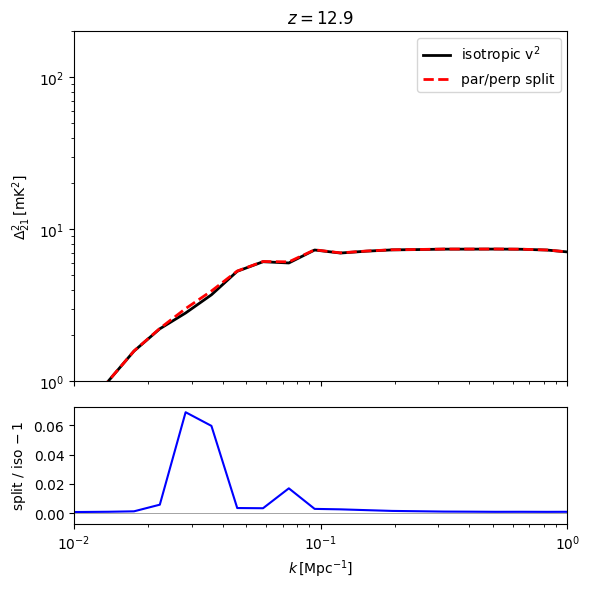

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.loglog(klist, Dsq_iso[iz],   'k',   lw=2.0, label=r'isotropic v$^2$')
ax.loglog(klist, Dsq_split[iz], 'r--', lw=2.0, label='par/perp split')
ax.set_ylabel(r'$\Delta^2_{21}\,[\mathrm{mK}^2]$')
ax.set_xlim(1e-2, 1.0)
ax.set_ylim(1, 200)
ax.set_title(f'$z = {zlist[iz]:.1f}$')
ax.legend()

ax = axes[1]
ax.semilogx(klist, Dsq_split[iz] / Dsq_iso[iz] - 1.0, 'b')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel(r'$k\,[\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'split / iso $-\,1$')
fig.tight_layout()

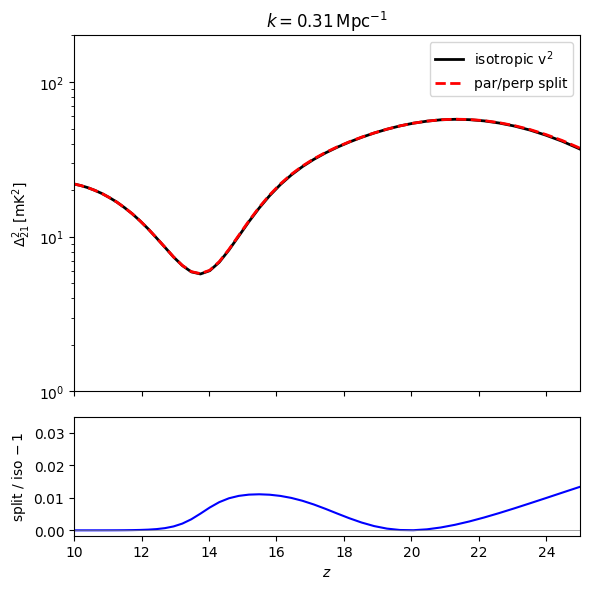

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.semilogy(zlist, Dsq_iso[:, ik],   'k',   lw=2.0, label=r'isotropic v$^2$')
ax.semilogy(zlist, Dsq_split[:, ik], 'r--', lw=2.0, label='par/perp split')
ax.set_ylabel(r'$\Delta^2_{21}\,[\mathrm{mK}^2]$')
ax.set_xlim(10, 25)
ax.set_ylim(1, 200)
ax.set_title(f'$k = {klist[ik]:.2f}\\,\\mathrm{{Mpc}}^{{-1}}$')
ax.legend()

ax = axes[1]
ax.plot(zlist, Dsq_split[:, ik] / Dsq_iso[:, ik] - 1.0, 'b')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel(r'$z$')
ax.set_ylabel(r'split / iso $-\,1$')
fig.tight_layout()

## 6. Linear PS sanity check

The eta-mode dispatch only enters the **non-linear** correlation function
(`get_xi_Sum_2ExpEta`). The linear power spectrum should be identical
between the two runs.

max |Deltasq_T21_lin split/iso - 1| = 0.000e+00  (expected ~0)


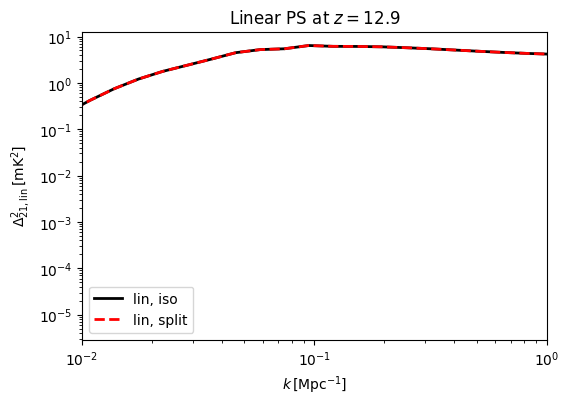

In [9]:
Dsq_lin_iso   = PS21_iso.Deltasq_T21_lin
Dsq_lin_split = PS21_split.Deltasq_T21_lin
max_lin_diff = float(np.nanmax(np.abs(Dsq_lin_split / Dsq_lin_iso - 1.0)))
print(f'max |Deltasq_T21_lin split/iso - 1| = {max_lin_diff:.3e}  (expected ~0)')

plt.figure(figsize=(6, 4))
plt.loglog(klist, Dsq_lin_iso[iz],   'k',   lw=2.0, label='lin, iso')
plt.loglog(klist, Dsq_lin_split[iz], 'r--', lw=2.0, label='lin, split')
plt.xlabel(r'$k\,[\mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$\Delta^2_{21,\mathrm{lin}}\,[\mathrm{mK}^2]$')
plt.title(f'Linear PS at $z={zlist[iz]:.1f}$')
plt.legend()
plt.xlim(1e-2, 1.0);